In [1]:
import numpy as np
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
import re


In [2]:
apt_data = pd.read_csv('/kaggle/input/datasets/micahluftig/recidivism-eval-data/apt_data.csv')
p_data = pd.read_csv('/kaggle/input/datasets/micahluftig/recidivism-eval-data/p_data.csv')

In [3]:
print(p_data.head())
print(p_data.columns)

  animal_id  age_at_first_visit spp    akc_group         outcome_time sex_out  \
0   a006100                10.0  k9     sporting                  NaN     NaN   
1   a047759                10.0  k9        hound  2014-04-07 15:12:00       n   
2   a134067                16.0  k9      herding  2013-11-16 11:54:00       n   
3   a141142                15.0  k9  mixed_breed  2013-11-17 11:40:00       s   
4   a163459                15.0  k9      terrier  2014-11-14 19:28:00       f   

   pregnant_o_nursing  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  
Index(['animal_id', 'age_at_first_visit', 'spp', 'akc_group', 'outcome_time',
       'sex_out', 'pregnant_o_nursing'],
      dtype='object')


In [4]:
conn = sqlite3.connect('shelter_data.db')
apt_data.to_sql('apt_data', conn, index=False, if_exists='replace')
p_data.to_sql('p_data', conn, index=False, if_exists='replace')

query = """
WITH adoptions AS (
    SELECT
        A.intake_id, A.animal_id,
        A.intake_time, A.discharge_time,
        A.intake_reason AS first_reason, A.los_days,
        P.spp, P.akc_group, P.age_at_first_visit
    FROM apt_data A
    JOIN p_data P ON P.animal_id = A.animal_id
    WHERE LOWER(A.outcome_type_raw) = 'adoption'
),
future_intakes AS (
    SELECT animal_id, intake_time AS future_intake_time
    FROM apt_data
),
return_check AS (
    SELECT
        a.*,
        MIN(
            CASE WHEN f.future_intake_time > a.discharge_time
                  AND julianday(f.future_intake_time) - julianday(a.discharge_time) <= 30
                 THEN f.future_intake_time END
        ) AS return_intake_time
    FROM adoptions a
    LEFT JOIN future_intakes f ON f.animal_id = a.animal_id
    GROUP BY a.intake_id
)
SELECT
    *,
    CASE WHEN return_intake_time IS NOT NULL THEN 1 ELSE 0 END AS returned,
    ROUND(julianday(return_intake_time) - julianday(discharge_time), 2) AS return_time_days
FROM return_check;
"""
recidivism_result = pd.read_sql_query(query, conn)
conn.close()

date_cols = ['intake_time', 'discharge_time', 'return_intake_time']
recidivism_result[date_cols] = recidivism_result[date_cols].apply(lambda col: pd.to_datetime(col))

dataset_max_date = recidivism_result['intake_time'].max()
recidivism_result['window_end'] = recidivism_result['discharge_time'] + pd.Timedelta(days=30)
recidivism_result['censored'] = (recidivism_result['returned'] == 0) & (recidivism_result['window_end'] > dataset_max_date)
recidivism_result = recidivism_result[~recidivism_result['censored']].copy()

print(recidivism_result['returned'].value_counts())
print(recidivism_result['return_time_days'].describe())

returned
0    50690
1     3718
Name: count, dtype: int64
count    3718.000000
mean        7.862743
std         7.799964
min         0.000000
25%         1.790000
50%         4.905000
75%        12.105000
max        30.000000
Name: return_time_days, dtype: float64


In [5]:
def table_check(df, df_name, unique_id) -> pd.DataFrame:
    print(f'Beginning errorcheck for: {df_name} ***')
    print(f'\n--- Null Value Check ---')
    for column in df.columns: 
        null_count = df[column].isna().sum() 
        print(f'{column} nulls: {null_count}')
    print('\n')
    
    print(f'--- Integrity Check ---')
    if unique_id in df.columns:
        duplicate_count = df[unique_id].duplicated().sum()
        print(f'Total {unique_id} duplicates: {duplicate_count}')
    else:
        print(f"WARNING: {unique_id} not found for duplication check.")
    print('\n')
    print(f'\n--- Data Type Audit (DF.dtypes) ---')
    print(df.dtypes)
    
    print(f'\n--- Numerical Sanity Check (DF.describe) ---')
    
    numeric_cols = df.select_dtypes(include = ['int64', 'float64', 'Int64', 'int32']).columns
    if not numeric_cols.empty:
        print(df[numeric_cols].describe())
    else:
        print('No standard numerical columns found for description.')

    print(f'\n--- Categorical Value Audit (Top 10 Counts) ---')
    object_cols = df.select_dtypes(include=['object', 'string[python]']).columns

    for column in object_cols:
        print(f'\n{column.upper()}:')
        print(df[column].value_counts().nlargest(10))

    

    print('\n\n\n')

    return df

In [6]:
x = table_check(recidivism_result, 'recidivism_result', 'animal_id')

Beginning errorcheck for: recidivism_result ***

--- Null Value Check ---
intake_id nulls: 0
animal_id nulls: 0
intake_time nulls: 0
discharge_time nulls: 0
first_reason nulls: 0
los_days nulls: 0
spp nulls: 0
akc_group nulls: 0
age_at_first_visit nulls: 0
return_intake_time nulls: 50690
returned nulls: 0
return_time_days nulls: 50690
window_end nulls: 0
censored nulls: 0


--- Integrity Check ---
Total animal_id duplicates: 5169



--- Data Type Audit (DF.dtypes) ---
intake_id                     object
animal_id                     object
intake_time           datetime64[ns]
discharge_time        datetime64[ns]
first_reason                  object
los_days                     float64
spp                           object
akc_group                     object
age_at_first_visit           float64
return_intake_time    datetime64[ns]
returned                       int64
return_time_days             float64
window_end            datetime64[ns]
censored                        bool
dtype: ob

In [7]:
def normality_test(df, y_axis, x_axis):
    
    df_clean = df.dropna(subset=[y_axis, x_axis]).copy()
    
    transformations = {
        f'Regular ({y_axis})': df_clean[y_axis],
        f'Log (log({y_axis} + 0.001))': np.log(df_clean[y_axis] + 0.001),
        f'Sqrt (sqrt({y_axis}))': np.sqrt(df_clean[y_axis]),
        f'Log-Sqrt (log(sqrt({y_axis}) + 0.001))': np.log(np.sqrt(df_clean[y_axis]) + 0.001)
    }
    
    print('=' * 50)
    print(f'{y_axis} by {x_axis}\n\n')
    
    
    for label, y_values in transformations.items():
        
        df_clean['temp_y'] = y_values
        residuals = smf.ols(f'temp_y ~ {x_axis}', data=df_clean).fit().resid
        stat, p_val = stats.shapiro(residuals)
        
        
        print(f'{label}')
        print(f'Transformation: {label}')
        print(f'  W = {stat:.5f}, p-value = {p_val:.5e}\n')
        
    print('=' * 50)
    return df

# normality_test(
#     df = recidivism_result,
#     y_axis = 'return_time_days',
#     x_axis = 'first_reason'
# )

def normality_plot(df, y_axis):
    epsilon = 0.001
    y_clean = df[y_axis].dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    
    transformations = [
        ('regular', y_clean),
        ('sqrt', np.sqrt(y_clean)),
        ('log', np.log(y_clean + epsilon)),
        ('log(sqrt)', np.log(np.sqrt(y_clean) + epsilon))
    ]
    
   
    for (title, y_values), ax in zip(transformations, axes.flat):
        stats.probplot(y_values, plot=ax)
        ax.set_title(f'Normal Q-Q: {title}')
    plt.tight_layout()
    plt.show()
    
    return df

def kruskal_wallis(df, y_axis, x_axis):
    # 1. Gather the data groups in one clean line
    groups = [group[y_axis] for name, group in df.groupby(x_axis, observed = False)]
    
    # 2. Run the test
    stat, p_val = stats.kruskal(*groups)
    
    # 3. Print the results
    print('=' * 50)
    print(f'Kruskal-Wallis rank sum test')
    print(f'Data: {y_axis} by {x_axis}')
    print(f'  Chi-squared = {stat:.5f}, p-value = {p_val:.5e}')
    print('=' * 50)
    
    return df


def behavior_v_return_time(df, y_axis, x_axis) -> pd.DataFrame:
    return (df
            .pipe(normality_test, y_axis, x_axis)
            .pipe(normality_plot, y_axis)
            .pipe(kruskal_wallis, y_axis, x_axis)
    )

return_time_days by first_reason


Regular (return_time_days)
Transformation: Regular (return_time_days)
  W = 0.85031, p-value = 1.22607e-50

Log (log(return_time_days + 0.001))
Transformation: Log (log(return_time_days + 0.001))
  W = 0.93516, p-value = 1.65513e-37

Sqrt (sqrt(return_time_days))
Transformation: Sqrt (sqrt(return_time_days))
  W = 0.94920, p-value = 4.61351e-34

Log-Sqrt (log(sqrt(return_time_days) + 0.001))
Transformation: Log-Sqrt (log(sqrt(return_time_days) + 0.001))
  W = 0.88725, p-value = 5.82080e-46



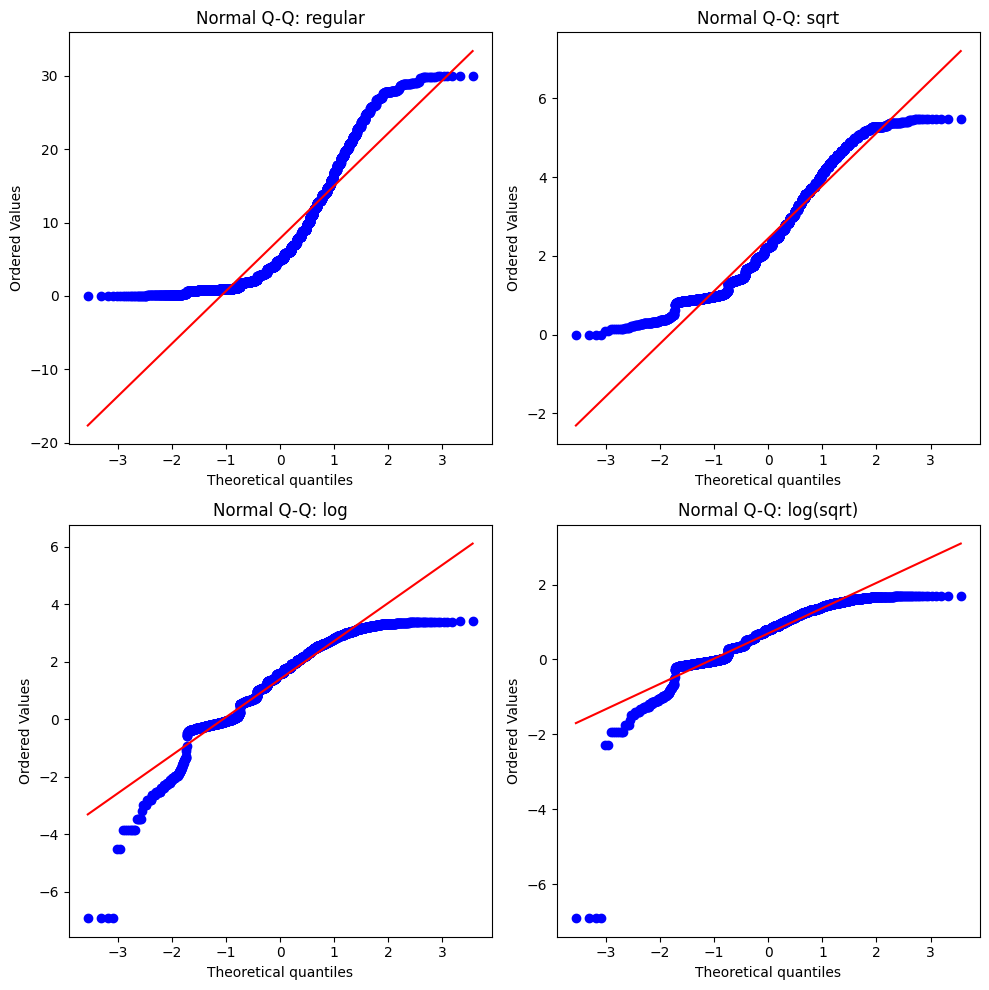

Kruskal-Wallis rank sum test
Data: return_time_days by first_reason
  Chi-squared = nan, p-value = nan


In [8]:
behavior_v_return_time_output = behavior_v_return_time(recidivism_result, 'return_time_days', 'first_reason')

In [9]:
# Regression analysis: predict return_time_days from LOS, age, species, and intake reason
regression_df = recidivism_result.copy()
regression_df = regression_df.dropna(subset=['return_time_days', 'los_days', 'age_at_first_visit', 'first_reason', 'spp']).copy()
regression_df = regression_df[regression_df['return_time_days'] > 0]  # only positive return times
regression_df['first_reason'] = regression_df['first_reason'].astype(str).str.strip()
regression_df['spp'] = regression_df['spp'].astype(str).str.strip()
regression_df = pd.get_dummies(regression_df, columns=['first_reason', 'spp'], drop_first=True)
predictors = ['los_days', 'age_at_first_visit'] + [col for col in regression_df.columns if col.startswith('first_reason_') or col.startswith('spp_')]
formula = 'return_time_days ~ ' + ' + '.join(predictors)
model = smf.ols(formula=formula, data=regression_df).fit()
print('\nRegression formula:')
print(formula)
print('\nRegression summary:')
print(model.summary())



Regression formula:
return_time_days ~ los_days + age_at_first_visit + first_reason_medical + first_reason_other + first_reason_routine + spp_k9 + spp_other

Regression summary:
                            OLS Regression Results                            
Dep. Variable:       return_time_days   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.052
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-05
Time:                        13:46:25   Log-Likelihood:                -12881.
No. Observations:                3714   AIC:                         2.578e+04
Df Residuals:                    3706   BIC:                         2.583e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               

In [10]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Print the raw category counts so you can see the distribution
print("--- Category Distribution ---")
print(recidivism_result['first_reason'].value_counts())
print("\n" + "="*50 + "\n")

# 2. Create a clean binary feature (1 if medical, 0 if routine or other)
recidivism_result['is_medical'] = (recidivism_result['first_reason'] == 'medical').astype(float)

# 3. Fit the updated OLS model using our new binary column
# Note: We completely remove C(first_reason) to stop the severe multicollinearity
updated_model = smf.ols(
    formula='return_time_days ~ age_at_first_visit + los_days + is_medical', 
    data=recidivism_result
).fit()

# 4. View the new results
print("--- Updated Model Summary ---")
print(updated_model.summary())


--- Category Distribution ---
first_reason
routine     50513
medical      3788
other          73
behavior       34
Name: count, dtype: int64


--- Updated Model Summary ---
                            OLS Regression Results                            
Dep. Variable:       return_time_days   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.793
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           0.000145
Time:                        13:46:25   Log-Likelihood:                -12902.
No. Observations:                3718   AIC:                         2.581e+04
Df Residuals:                    3714   BIC:                         2.584e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std 

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

              precision    recall  f1-score   support

   No Return       0.97      0.53      0.69     10138
    Returned       0.11      0.76      0.19       744

    accuracy                           0.55     10882
   macro avg       0.54      0.65      0.44     10882
weighted avg       0.91      0.55      0.65     10882



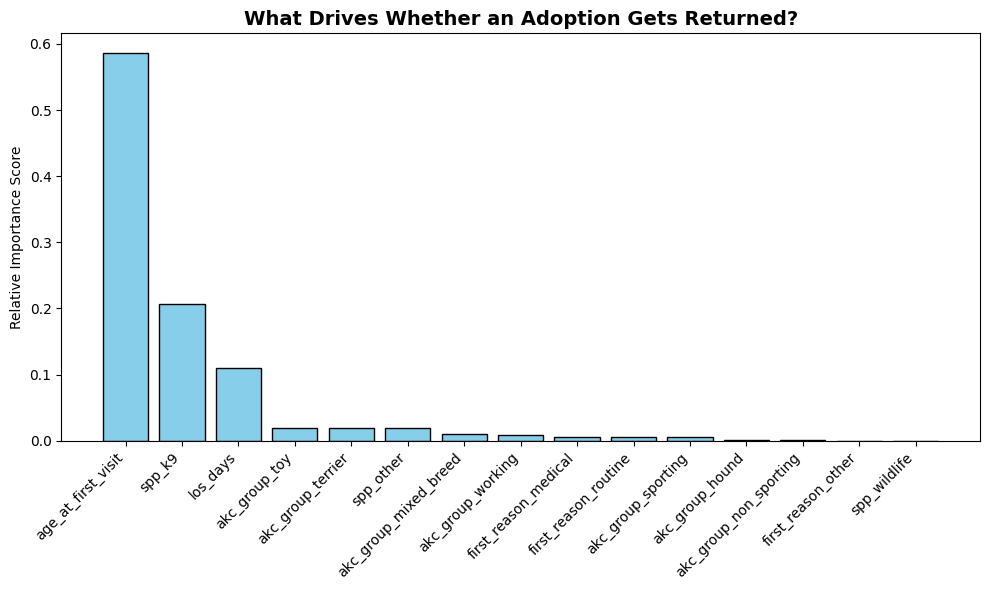

In [12]:
feature_cols_extra = ['spp', 'akc_group', 'first_reason', 'los_days', 'age_at_first_visit']
model_df = recidivism_result.dropna(subset=feature_cols_extra).copy()

FEATURE_ORDER = [
    "los_days", "age_at_first_visit",
    "spp_k9", "spp_other", "spp_wildlife",
    "akc_group_hound", "akc_group_mixed_breed", "akc_group_non_sporting",
    "akc_group_sporting", "akc_group_terrier", "akc_group_toy", "akc_group_working",
    "first_reason_medical", "first_reason_other", "first_reason_routine",
]

def build_features(df):
    X = pd.DataFrame(index=df.index)
    X['los_days'] = df['los_days']
    X['age_at_first_visit'] = df['age_at_first_visit']
    spp = df['spp'].astype(str).str.lower()
    X['spp_k9'] = (spp == 'k9').astype(int)
    X['spp_wildlife'] = (spp == 'wildlife').astype(int)
    X['spp_other'] = ((~spp.isin(['k9', 'fel'])).astype(int) - X['spp_wildlife']).clip(lower=0)
    akc = df['akc_group'].astype(str).str.lower()
    for group in ['hound', 'mixed_breed', 'non_sporting', 'sporting', 'terrier', 'toy', 'working']:
        X[f'akc_group_{group}'] = (akc == group).astype(int)
    reason = df['first_reason'].astype(str).str.lower()
    for r in ['medical', 'other', 'routine']:
        X[f'first_reason_{r}'] = (reason == r).astype(int)
    return X[FEATURE_ORDER]

X = build_features(model_df)
y = model_df['returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Return', 'Returned']))

importances = pd.Series(rf_model.feature_importances_, index=FEATURE_ORDER).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.title("What Drives Whether an Adoption Gets Returned?", fontsize=14, fontweight='bold')
plt.bar(range(len(importances)), importances.values, color='skyblue', edgecolor='black')
plt.xticks(range(len(importances)), importances.index, rotation=45, ha='right', fontsize=10)
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Probability Calibration
# The Random Forest above uses class_weight='balanced' to prioritize
# recall given the low 6.8% base rate. This improves classification
# performance, but it also means predict_proba() output is no longer a
# calibrated probability -- raw predictions cluster far above the true
# base rate (mean predicted ~43% vs. actual ~6.8%). This step corrects
# that, so the deployed app's displayed percentages mean what they claim.
# ============================================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import joblib

calibrated_model = CalibratedClassifierCV(FrozenEstimator(rf_model), method='isotonic')
calibrated_model.fit(X_test, y_test)

test_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
test_proba_raw = rf_model.predict_proba(X_test)[:, 1]

print('Mean predicted probability (raw, uncalibrated):', test_proba_raw.mean())
print('Mean predicted probability (calibrated):', test_proba_calibrated.mean())
print('Actual base rate:', y_test.mean())

joblib.dump(calibrated_model, 'recidivism_model.pkl')
print('\nSaved recidivism_model.pkl (calibrated) -- this is the deployed artifact.')

Mean predicted probability (raw, uncalibrated): 0.42821480860116873
Mean predicted probability (calibrated): 0.0683697849659989
Actual base rate: 0.0683697849659989

Saved recidivism_model.pkl (calibrated) -- this is the deployed artifact.


In [13]:
!pip freeze > requirements.txt

Confusion Matrix:
[[5396 4742]
 [ 176  568]]

True Negatives: 5396, False Positives: 4742
False Negatives: 176, True Positives: 568


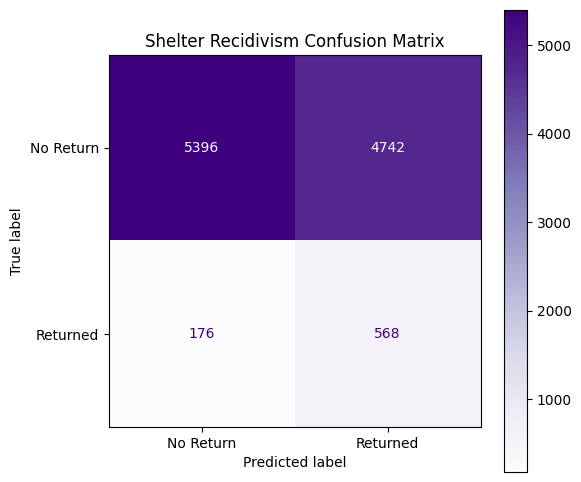


Return rate by length of stay (weeks):
               mean  count
los_weeks                 
0.0        0.081539   4366
1.0        0.070189  21955
2.0        0.087471   5236
3.0        0.077443   3254
4.0        0.069509   2791
5.0        0.063945   2596
6.0        0.070769   2275
7.0        0.051459   1885
8.0        0.048024   1645
9.0        0.046348   1424
10.0       0.042039   1118
11.0       0.049031    877
12.0       0.046269    670
13.0       0.075926    540
14.0       0.060345    464
15.0       0.056548    336
16.0       0.070423    284
17.0       0.051095    274
18.0       0.056338    213
19.0       0.039548    177


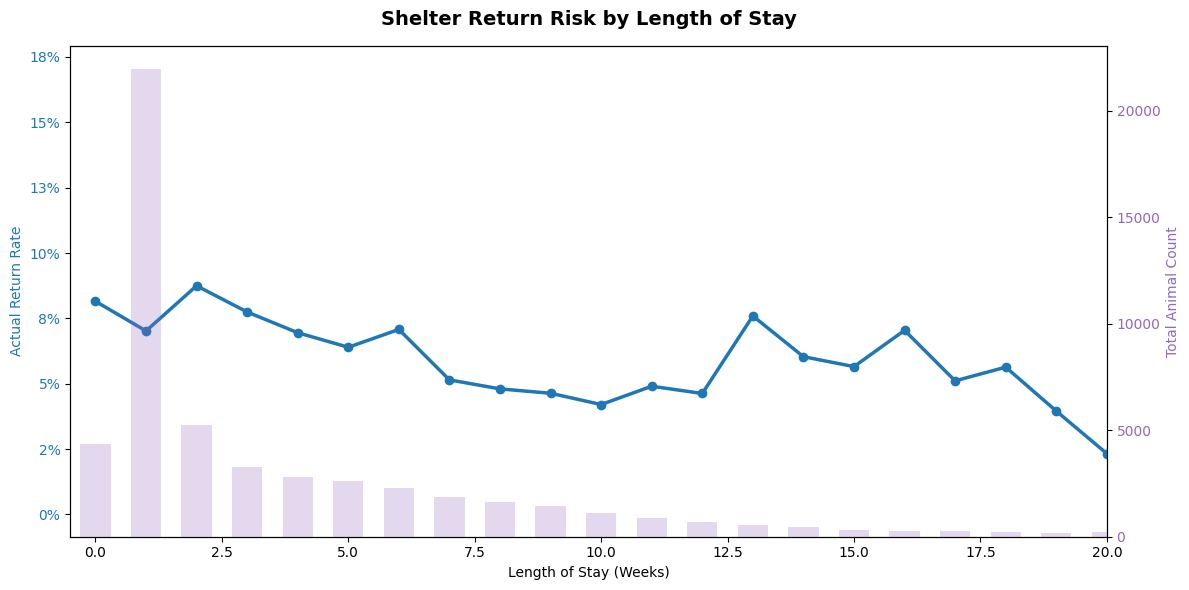


Species distribution (%):
spp
k9           60.130863
fel          38.527422
other         0.948390
bird          0.365755
livestock     0.014704
wildlife      0.012866
Name: proportion, dtype: float64


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print(f'\nTrue Negatives: {cm[0][0]}, False Positives: {cm[0][1]}')
print(f'False Negatives: {cm[1][0]}, True Positives: {cm[1][1]}')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Return', 'Returned'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Purples', ax=ax)
plt.title('Shelter Recidivism Confusion Matrix')
plt.savefig('shelter_recidivism_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

model_df['los_weeks'] = (model_df['los_days'] / 7).round()
tipping_point_summary = model_df.groupby('los_weeks')['returned'].agg(['mean', 'count'])
tipping_point_summary = tipping_point_summary[tipping_point_summary['count'] >= 20]
print('\nReturn rate by length of stay (weeks):')
print(tipping_point_summary.head(20))

fig, ax1 = plt.subplots(figsize=(12, 6))
color = '#1f77b4'
ax1.set_xlabel('Length of Stay (Weeks)')
ax1.set_ylabel('Actual Return Rate', color=color)
ax1.plot(tipping_point_summary.index, tipping_point_summary['mean'], color=color, marker='o', linewidth=2.5, label='Return Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_xlim(-0.5, 20)

ax2 = ax1.twinx()
color2 = '#9467bd'
ax2.set_ylabel('Total Animal Count', color=color2)
ax2.bar(tipping_point_summary.index, tipping_point_summary['count'], color=color2, alpha=0.25, width=0.6, label='Animal Volume')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Shelter Return Risk by Length of Stay', fontsize=14, pad=15, fontweight='bold')
fig.tight_layout()
plt.savefig('shelter_return_risk_by_length_of_stay.png', dpi=300, bbox_inches='tight')
plt.show()

species_pct = model_df['spp'].value_counts(normalize=True) * 100
print('\nSpecies distribution (%):')
print(species_pct)

In [15]:
import joblib
joblib.dump(rf_model, 'recidivism_model.pkl')

['recidivism_model.pkl']

In [16]:
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)